# Generic Training Workflow: Load Data, Select Model, Train, and Evaluate

This notebook provides a **generic training pipeline** for ozone field prediction. It can load different architectures from `model_lib/` (for example `MLP`, `MLP2`, `3DCNN`, `CNN+LSTM`) and train them with consistent preprocessing, callbacks, and evaluation.

The workflow includes:

1. **Data Loading & Preprocessing**: Load meteorological predictors and ozone targets from NetCDF-based inputs
2. **Feature/Target Setup**: Build the predictor list (`met_only` or `with_rasterized_ozone`) and define the ozone target
3. **Model Loading & Hyperparameter Overrides**: Dynamically import the selected model module and override defaults through `model_config`
4. **K-fold Training**: Train with K-fold cross-validation (with temporal sequencing when required by the model)
5. **Model Selection & Storage**: Keep the best fold model and store diagnostics in `results`
6. **Visualization**: Plot training curves and visualize prediction, residual, and relative error maps

The code is organized to make experiments reproducible and easy to adapt across model types.

# Imports

Import core libraries for model training (`tensorflow`, `numpy`), plotting (`matplotlib`), data handling (`iris`), and helper functions from `model_lib.ml_utils`.

In [1]:
import importlib
import os
import sys

import tensorflow as tf
from tensorflow.keras.utils import plot_model

#import matplotlib.pyplot as plt
import warnings
# turn off futurewarning from iris
warnings.filterwarnings("ignore", category=FutureWarning)
# turn off netcdf unknown variable warning from iris
warnings.filterwarnings("ignore", category=UserWarning, message=".*NetCDF variable.*")
# turn off IrisCfNonSpanningVarWarning
warnings.filterwarnings("ignore", category=UserWarning, message=".*IrisCfNonSpanningVarWarning.*")

import numpy as np

from matplotlib import pyplot as plt

import iris
iris.FUTURE.save_split_attrs = True
# iris.FUTURE.datum_support = False

from model_lib.ml_utils import (
    is_running_in_notebook,
    load_and_preprocess_training_data,
    parse_arguments,
)

# User Parameters

Set the model family, data frequency, sequence length, and feature configuration.  
When run as a script, CLI arguments from `parse_arguments()` can override these notebook defaults.

In [ ]:
# User parameters
# Note: Adjust these parameters as needed before running the notebook

# model_type = "MLP" 
# model_type = "2DCNN" 
# model_type = "3DCNN" 
# model_type = "CNN+LSTM" 
model_type = "UNet" 
# model_type = "convLSTM" 

with_rasterized_ozone = False  # Set to True to include rasterized ozone data as input features; False to use only meteorological variables
training_frequency = "daily"  # Set to "hourly" or "daily"
ndays = (
    93 if training_frequency == "daily" else 30
)  # Number of days to load (daily=93, hourly test=30)
sequence_length = (
    3 if training_frequency == "daily" else 48
)  # Daily: 3 steps. Hourly: 48 steps (2 days).

# Set number of k-folds for cross-validation (must be >=2)
k_folds = 5
print(f"\nUsing k-folds: {k_folds}. To change, set 'k_folds' to desired number of folds (must be >=2).")

load_data_verbose = False  # Set to True to print detailed data loading information

# Apply CLI arguments only when run from shell/script (skip in Jupyter notebook)
if not is_running_in_notebook():
    args = parse_arguments()
    training_frequency = args.training_frequency
    ndays = args.ndays
    model_type = args.model_type
    with_rasterized_ozone = args.with_rasterized_ozone
    sequence_length = args.sequence_length
    k_folds = args.k_folds


# config_name  (with_rasterized_ozone  or met_only) is used as key in results dict to store model, history, and tensors
config_name = "with_rasterized_ozone" if with_rasterized_ozone else "met_only"

# Print the parameters to verify
print("\n" + "=" * 80)
print("SCRIPT SETTINGS:")
print("=" * 80)
print(f"Model type: {model_type}")
print(f"Training frequency: {training_frequency}")
print(f"Number of days: {ndays}")
print(f"Include rasterized ozone as input features: {with_rasterized_ozone}")   
print(f"Configuration name: {config_name}")
print(f"Number of k-folds for cross-validation: {k_folds}")
print(f"Sequence length (only for LSTM type models): {sequence_length} time steps")


SCRIPT SETTINGS:
Model type: 3DCNN
Training frequency: daily
Number of days: 93
Include rasterized ozone as input features: False
Configuration name: met_only
Sequence length (only for LSTM type models): 3 time steps


# Feature & Target Definition and Data Loading

Define the meteorological predictor list and ozone target, optionally append rasterized ozone as an extra input channel, then load normalized training tensors and metadata (`ntime`, `nlat`, `nlon`, `nfeature`).

In [3]:
# Base meteorological features — shared by both configurations.
# The rasterized ozone channel is appended conditionally in the training loop.
base_feature_selection_list = [
    "air_pressure_at_sea_level",
    "air_temperature",
    "relative_humidity",
    "x_wind",
    "y_wind",
    "precipitation_amount",
    "photolysis_rate_of_nitrogen_dioxide",
]

target_selection_list = ["mass_concentration_of_ozone_in_air"]

#print(f"Base features ({len(base_feature_selection_list)}): {base_feature_selection_list}")

feature_selection_list = base_feature_selection_list.copy()
if with_rasterized_ozone:
    feature_selection_list.append("rasterized_aqum_O3_at_AURN_sites")

print(f"Features ({len(feature_selection_list)}): {feature_selection_list}")
print(f"Target: {target_selection_list}")

# load data

print("\n" + "="*80)
print(f"LOAD DATA FOR {model_type} MODEL {'WITH RASTERIZED OZONE' if with_rasterized_ozone else 'METEOROLOGICAL VARIABLES ONLY'}")
print("="*80)

data = load_and_preprocess_training_data(
    training_frequency=training_frequency,
    ndays=ndays,
    feature_selection_list=feature_selection_list,
    target_selection_list=target_selection_list,
    verbose=load_data_verbose,
)
x_all = data['xtrain_data_normalised'].astype(np.float32)  # (ntime, nlat, nlon, nfeature)
y_all = data['ytrain_data_normalised'].astype(np.float32)  # (ntime, nlat, nlon, 1)
feature_names = data['feature_names']
ntime = data['ntime']
nlat = data['nlat']
nlon = data['nlon']
nfeature = data['nfeature']
nfeature_multiplier = data['nfeature_multiplier']
#xtrain_cube_list_regridded = data['xtrain_cube_list_regridded']
#ytrain_cube_list = data['ytrain_cube_list']
ntarget = len(target_selection_list)

print(f"Loaded data shapes for {config_name}:")
print(f"  x_all shape: {x_all.shape}")
print(f"  y_all shape: {y_all.shape}")

Features (7): ['air_pressure_at_sea_level', 'air_temperature', 'relative_humidity', 'x_wind', 'y_wind', 'precipitation_amount', 'photolysis_rate_of_nitrogen_dioxide']
Target: ['mass_concentration_of_ozone_in_air']

LOAD DATA FOR 3DCNN MODEL METEOROLOGICAL VARIABLES ONLY
Loading training data from: processed_data/Daily_snapshots
Number of days to load: 93
Feature selection list: ['air_pressure_at_sea_level', 'air_temperature', 'relative_humidity', 'x_wind', 'y_wind', 'precipitation_amount', 'photolysis_rate_of_nitrogen_dioxide']
Target selection list: ['mass_concentration_of_ozone_in_air']
File multiplier based on frequency: 1
Expected number of files to load for Y-train: 93
Expected number of files to load for X-train: 93
Verbose mode is OFF: Detailed processing messages will not be printed.



/data/users/florent.malavelle/.conda/envs/MLFoundationsEnv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Loaded data shapes for met_only:
  x_all shape: (93, 112, 88, 7)
  y_all shape: (93, 112, 88, 1)


# Load Model and Train

Dynamically load the selected model module from `model_lib/`, apply hyperparameter overrides, then train with K-fold cross-validation.

## Model Import and Hyperparameter Setup

Import the module matching `model_type`, read its `hyperparameters`, apply optional `model_config` overrides, and define the number of CV folds (`k_folds`).

In [4]:
print("\n" + "="*80)
print(f"TRAINING {model_type} MODEL")
print("=" *80)

# remove _model_module from memory if it has been imported in a previous run to start from clean slate for this training run
if '_model_module' in locals():
    del _model_module

#remove hyperparameters from memory if it has been imported in a previous run to start from clean slate for this training run
if 'hyperparameters' in locals():
    del hyperparameters

# Dynamically import build_model from model_lib/{model_type}.py
_model_lib_dir = os.path.join(os.path.abspath("."), "model_lib")
if _model_lib_dir not in sys.path:
    sys.path.insert(0, _model_lib_dir)
_model_module = importlib.import_module(model_type)
build_model = _model_module.build_model
print(f"Loaded model definition: model_lib/{model_type}.py")

# Read hyperparameters from the loaded module object
if hasattr(_model_module, "hyperparameters"):
    hyperparameters = _model_module.hyperparameters
else:
    raise AttributeError(
        f"'model_lib/{model_type}.py' must define 'hyperparameters'."
    )


###################################################
# Build model config to override defaults in model_lib/{model_type}.py
###################################################

model_config = {
    #"hidden_units": (128, 64),
    "l2_lambda": 1e-5,
    "epochs": 50,
    "batch_size": 8,
    "learning_rate": 0.0003,
    "es_patience": 8,
    "lr_patience": 4,
    "reduce_factor": 0.3,
    "dropout_rate": 0.2,
    "min_lr": 1e-6,

}

# Keep callback/training settings in sync with model overrides
hyperparameters = {**hyperparameters, **model_config}

# print the hyperparameters for this model
print("\nModel hyperparameters:")
for key, value in hyperparameters.items():
    print(f"  {key}: {value}")




TRAINING 3DCNN MODEL
Loaded model definition: model_lib/3DCNN.py

Model hyperparameters:
  model_name: 3DCNN_ozone_forecaster
  temporal_sequencing: True
  spatial_filters: (32, 64)
  temporal_filters: (64, 32)
  dropout_rate: 0.2
  l2_lambda: 1e-05
  epochs: 50
  batch_size: 8
  learning_rate: 0.0003
  es_patience: 8
  lr_patience: 4
  min_lr: 1e-06
  reduce_factor: 0.3
  monitor_metric: val_loss
  compile_loss: mse
  compile_metrics: ['mae']

Using k-folds: 2. To change, set 'k-folds' to desired number of folds (must be >=2).


## K-fold Cross-Validation and Model Training

This cell runs the training pipeline for the selected configuration (`met_only` or `with_rasterized_ozone`):

- **Optional temporal sequencing**: Builds sliding windows `(sequence_length, nlat, nlon, nfeature)` for sequence-based models (`temporal_sequencing=True`)
- **K-fold split**: Creates contiguous folds and rotates the validation fold across the dataset
- **Model construction**: Calls `build_model(input_shape, **model_config)` per fold
- **Callbacks**: Uses `EarlyStopping` and `ReduceLROnPlateau` based on `monitor_metric`
- **Training**: Fits each fold and tracks fold-best validation metric
- **Best fold selection**: Keeps the model/history from the best-performing fold
- **Script save path**: Saves the best model under `Trained_models/` when running outside notebook
- **Results dictionary**: Stores tensors, best history/model, and CV diagnostics in `results[config_name]`

In [5]:
print("\n" + "="*80)
print(f"TRAINING {model_type} MODEL")
print("=" * 80)

# if a model has been build, remove from memory to start from clean slate for this training run
if 'model' in locals():
    del model

# results[config_name] = {model, history, xtrain_tensor, ytrain_tensor}
results = {}

if k_folds < 2:
    raise ValueError(f"k_folds must be >= 2, got {k_folds}")

# DATA SEQUENCING (if using LSTM or other time-series models; skip for MLP)
if hyperparameters["temporal_sequencing"]:
    print(f"\nApplying temporal sequencing with sequence length = {sequence_length}...")
    # Build supervised sequences: input = past meteorology maps, target = ozone map at last step
    n_samples = ntime - sequence_length + 1
    if n_samples <= 0:
        raise ValueError(f"sequence_length={sequence_length} is too large for ntime={ntime}")

    x_model = np.array(
        [x_all[i:i + sequence_length] for i in range(n_samples)],
        dtype=np.float32,
    )
    y_model = np.array(
        [y_all[i + sequence_length - 1] for i in range(n_samples)],
        dtype=np.float32,
    )
else:
    print("\nNo temporal sequencing needed for this model; using data as is.")
    x_model = x_all
    y_model = y_all
    n_samples = x_model.shape[0]

if n_samples < 2:
    raise ValueError(f"Need at least 2 samples for K-fold CV, got n_samples={n_samples}")
if n_samples < k_folds:
    print(f"Requested k_folds={k_folds} but only n_samples={n_samples}; reducing to {n_samples} folds.")
    k_folds = n_samples

print(f"Total samples for CV: {n_samples}")
print(f"x_model shape: {x_model.shape} | y_model shape: {y_model.shape}")
print(f"Using {k_folds}-fold cross-validation")

# Build contiguous folds to preserve temporal ordering inside each fold segment.
fold_indices = np.array_split(np.arange(n_samples), k_folds)
monitor_metric = hyperparameters["monitor_metric"]

best_model = None
best_history = None
best_val_metric = np.inf
best_fold = None
fold_best_metrics = []
fold_histories = []

for fold_id, val_idx in enumerate(fold_indices, start=1):
    train_idx = np.concatenate([idx for j, idx in enumerate(fold_indices) if j != (fold_id - 1)])

    x_train, y_train = x_model[train_idx], y_model[train_idx]
    x_val, y_val = x_model[val_idx], y_model[val_idx]

    print("\n" + "-" * 80)
    print(f"Fold {fold_id}/{k_folds}")
    print(f"Train samples: {x_train.shape[0]} | Val samples: {x_val.shape[0]}")
    print(f"x_train shape: {x_train.shape} | y_train shape: {y_train.shape}")
    print(f"x_val shape: {x_val.shape} | y_val shape: {y_val.shape}")

    # Build model: input_shape = (nlat, nlon, nfeature) for MLP, CNN; (sequence_length, nlat, nlon, nfeature) for LSTM
    input_shape = x_train.shape[1:]
    model = build_model(input_shape, **model_config)

    if fold_id == 1:
        # Print model summary only for the first fold to avoid cluttering output; the architecture is the same for all folds
        model.summary()
        # Save a diagram of the model.
        plot_model(model, to_file=f'{model_type}_diagram.png', show_shapes=True, show_layer_names=True)
        print(f"\n{model_type} model diagram saved as '{model_type}_diagram.png'.")

    # callbacks (EarlyStopping, ReduceLROnPlateau)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor_metric,
            patience=hyperparameters['es_patience'],
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=monitor_metric,
            factor=hyperparameters['reduce_factor'],
            patience=hyperparameters['lr_patience'],
            min_lr=hyperparameters['min_lr'],
            verbose=1
        )
    ]

    # training (history = model.fit(...))
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=hyperparameters['epochs'],
        batch_size=hyperparameters['batch_size'],
        callbacks=callbacks,
        verbose=1
    )

    if monitor_metric not in history.history:
        raise KeyError(
            f"Monitored metric '{monitor_metric}' was not found in training history keys: {list(history.history.keys())}"
        )

    fold_best_metric = float(np.min(history.history[monitor_metric]))
    fold_best_metrics.append(fold_best_metric)
    fold_histories.append(history)

    print(f"Best {monitor_metric} for fold {fold_id}: {fold_best_metric:.6f}")

    if fold_best_metric < best_val_metric:
        best_val_metric = fold_best_metric
        best_model = model
        best_history = history
        best_fold = fold_id

print("\n" + "-" * 80)
print(
    f"CV summary ({monitor_metric}) -> mean: {np.mean(fold_best_metrics):.6f}, "
    f"std: {np.std(fold_best_metrics):.6f}, best fold: {best_fold} ({best_val_metric:.6f})"
)

# saving best model when running as script
if not is_running_in_notebook():
    trained_model_path = "Trained_models"
    os.makedirs(trained_model_path, exist_ok=True)
    trained_model_name = f"{model_type}_model_{training_frequency}_{config_name}_kfold{int(k_folds)}.keras"
    save_path = os.path.join(trained_model_path, trained_model_name)
    best_model.save(save_path)
    print(f"Best fold model saved to: {save_path}")

# Store results for this configuration
results[config_name] = {
    "model": best_model,
    "history": best_history,
    "xtrain_tensor": tf.convert_to_tensor(x_model, dtype=tf.float32),
    "ytrain_tensor": tf.convert_to_tensor(y_model, dtype=tf.float32),
    "cv_fold_histories": fold_histories,
    "cv_fold_best_metrics": fold_best_metrics,
    "cv_best_fold": best_fold,
    "cv_monitor_metric": monitor_metric,
}

print("\n" + "="*80)
print("TRAINING COMPLETE - best fold model stored in 'results' with CV diagnostics")
print("="*80)



TRAINING 3DCNN MODEL

Applying temporal sequencing with sequence length = 3...
Total samples for CV: 91
x_model shape: (91, 3, 112, 88, 7) | y_model shape: (91, 112, 88, 1)
Using 2-fold cross-validation

--------------------------------------------------------------------------------
Fold 1/2
Train samples: 45 | Val samples: 46
x_train shape: (45, 3, 112, 88, 7) | y_train shape: (45, 112, 88, 1)
x_val shape: (46, 3, 112, 88, 7) | y_val shape: (46, 112, 88, 1)


Model: "3DCNN_ozone_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ meteo_sequence (InputLayer)     │ (None, 3, 112, 88, 7)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 3, 112, 88, 32) │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 112, 88, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 112, 88, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 3, 112, 88, 64) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 3, 112, 88, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 112, 88, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 3, 112, 88, 64) │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 112, 88, 64) │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 112, 88, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 3, 112, 88, 32) │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 112, 88, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 112, 88, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features_at_t (Lambda)          │ (None, 112, 88, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ozone_forecast (Conv2D)         │ (None, 112, 88, 1)     │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,873 (155.75 KB)

 Trainable params: 39,489 (154.25 KB)

...


3DCNN model diagram saved as '3DCNN_diagram.png'.
Epoch 1/50


2026-03-30 21:13:38.110782: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 249790464 exceeds 10% of free system memory.
2026-03-30 21:13:38.110833: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 249790464 exceeds 10% of free system memory.
2026-03-30 21:13:38.800656: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 238436352 exceeds 10% of free system memory.
2026-03-30 21:13:38.801714: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 238436352 exceeds 10% of free system memory.


1/6 ━━━━━━━━━━━━━━━━━━━━ 42s 8s/step - loss: 2.6411 - mae: 1.1797

2026-03-30 21:13:39.804125: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 249790464 exceeds 10% of free system memory.


6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 2.1369 - mae: 1.0768 - val_loss: 0.4075 - val_mae: 0.6299 - learning_rate: 3.0000e-04
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - loss: 1.4459 - mae: 0.8995 - val_loss: 0.3393 - val_mae: 0.5725 - learning_rate: 3.0000e-04
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - loss: 1.1263 - mae: 0.7880 - val_loss: 0.2861 - val_mae: 0.5231 - learning_rate: 3.0000e-04
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - loss: 0.9136 - mae: 0.7048 - val_loss: 0.2459 - val_mae: 0.4837 - learning_rate: 3.0000e-04
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - loss: 0.7472 - mae: 0.6356 - val_loss: 0.2251 - val_mae: 0.4623 - learning_rate: 3.0000e-04
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - loss: 0.6262 - mae: 0.5785 - val_loss: 0.2169 - val_mae: 0.4538 - learning_rate: 3.0000e-04
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - loss: 0.5366 - mae: 0.5322 - val_loss: 0.2097 - val_mae: 0.4462 - learning_rate: 3.0000e-04
Epoch 8/50
6/6 ━━

# Training Curves and Prediction Diagnostics

The following cells visualize the best-fold training history (`loss`, `val_loss`, `mae`, `val_mae`) and then show sample maps of true ozone, predicted ozone, residuals, and relative error.

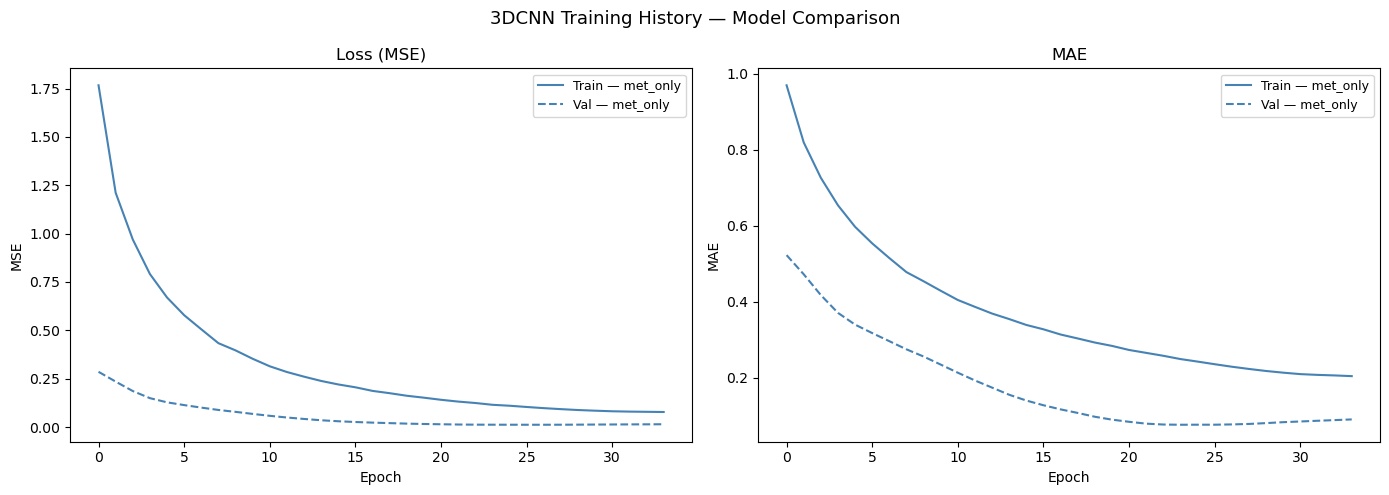

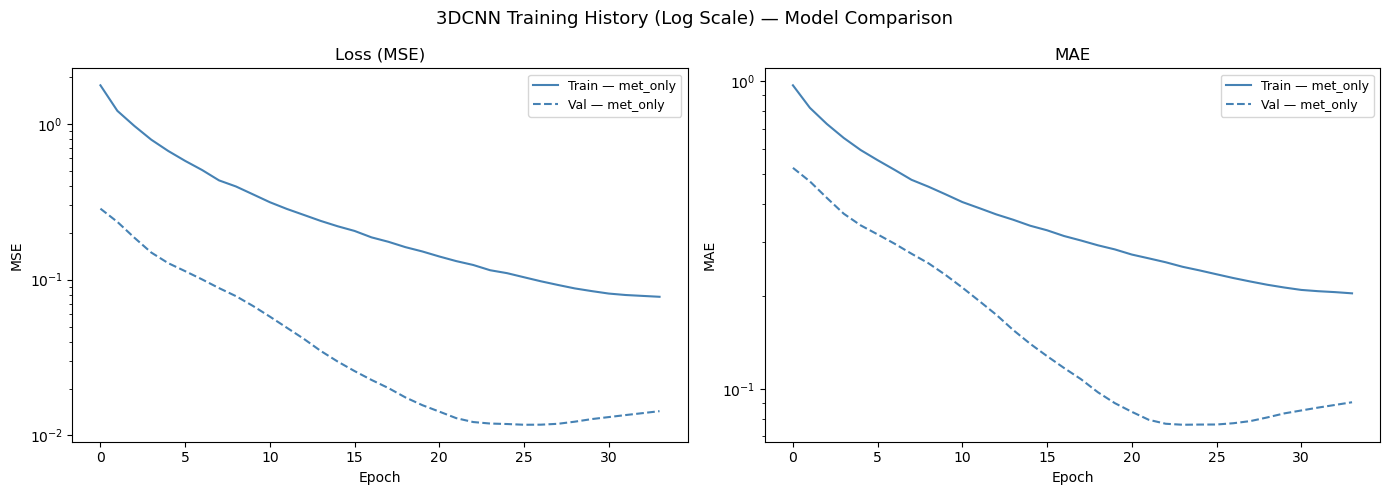

In [6]:
# -------------------------------------------------------------------------
# Show training curves for  configuration 
# Only in a jupyter notebook 
# -------------------------------------------------------------------------
if is_running_in_notebook():
    colors = {f"{config_name}": color for config_name, color in zip(results.keys(), ["steelblue", "tomato", "green", "purple"])}  # Assign same color to all lines of the same config

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_type} Training History — Model Comparison", fontsize=13)

    for config_name, res in results.items():
        hist  = res["history"].history
        color = colors.get(config_name, None)
        axes[0].plot(hist["loss"],     color=color, label=f"Train — {config_name}")
        axes[0].plot(hist["val_loss"], color=color, linestyle="--", label=f"Val — {config_name}")
        axes[1].plot(hist["mae"],      color=color, label=f"Train — {config_name}")
        axes[1].plot(hist["val_mae"],  color=color, linestyle="--", label=f"Val — {config_name}")

    for ax, title, ylabel in zip(axes, ["Loss (MSE)", "MAE"], ["MSE", "MAE"]):
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # repeat using log y-scale
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_type} Training History (Log Scale) — Model Comparison", fontsize=13)
    for config_name, res in results.items():
        hist  = res["history"].history
        color = colors.get(config_name, None)
        axes[0].plot(hist["loss"],     color=color, label=f"Train — {config_name}")
        axes[0].plot(hist["val_loss"], color=color, linestyle="--", label=f"Val — {config_name}")
        axes[1].plot(hist["mae"],      color=color, label=f"Train — {config_name}")
        axes[1].plot(hist["val_mae"],  color=color, linestyle="--", label=f"Val — {config_name}")
    for ax, title, ylabel in zip(axes, ["Loss (MSE)", "MAE"], ["MSE", "MAE"]):
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_yscale("log")
        ax.legend(fontsize=9)
        
    plt.tight_layout()
    plt.show()
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 863ms/step

=== Predictions: met_only with model 3DCNN ===


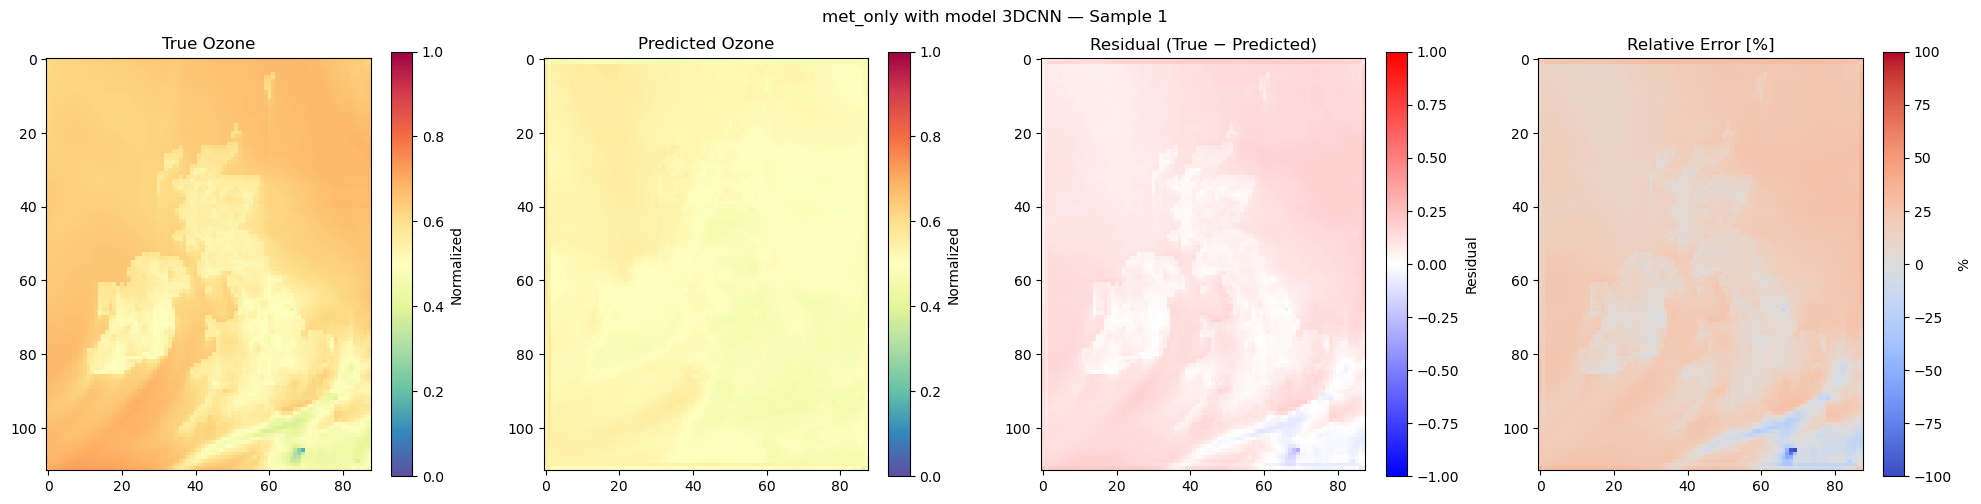

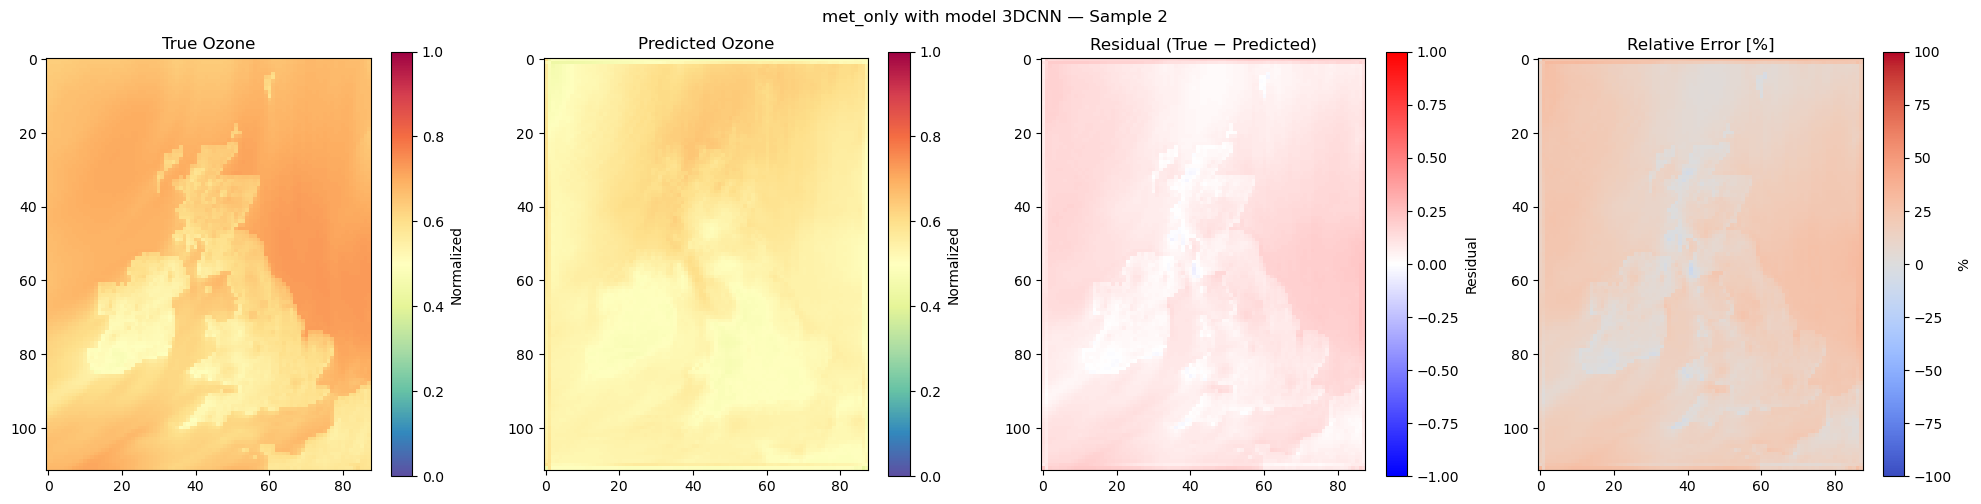

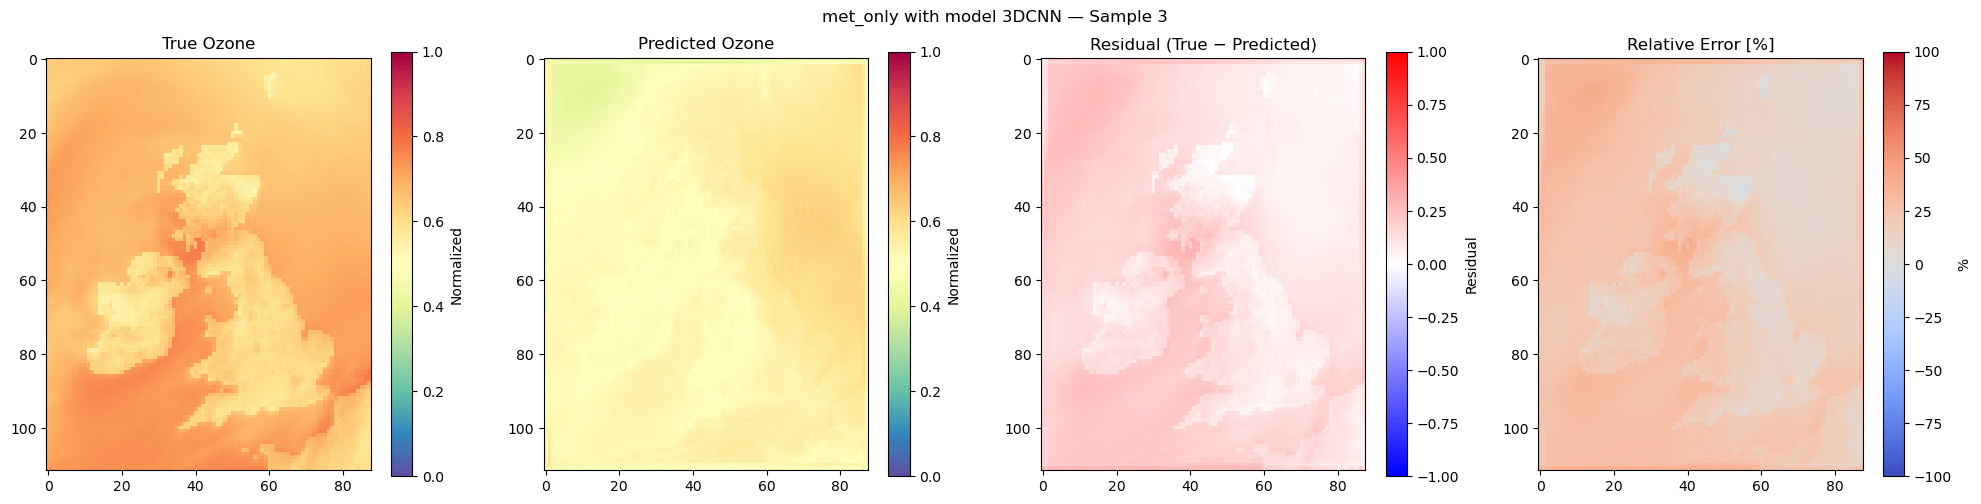

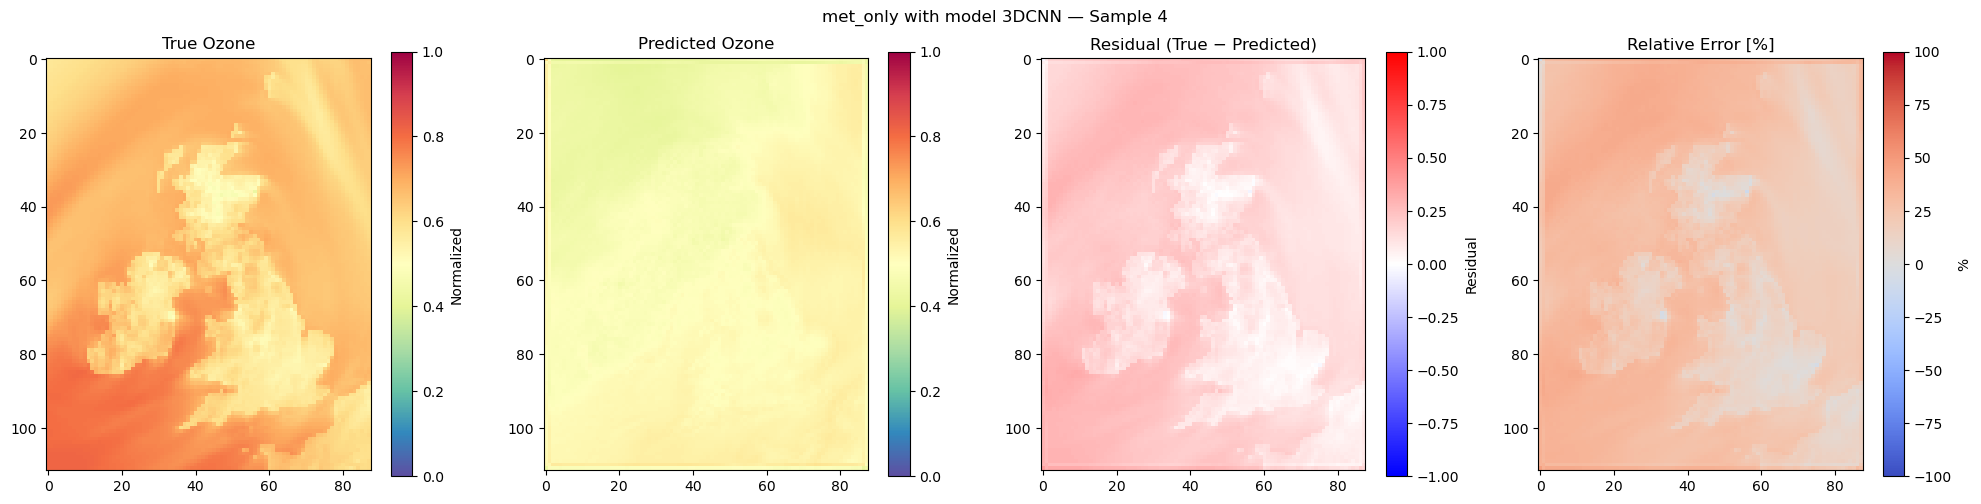

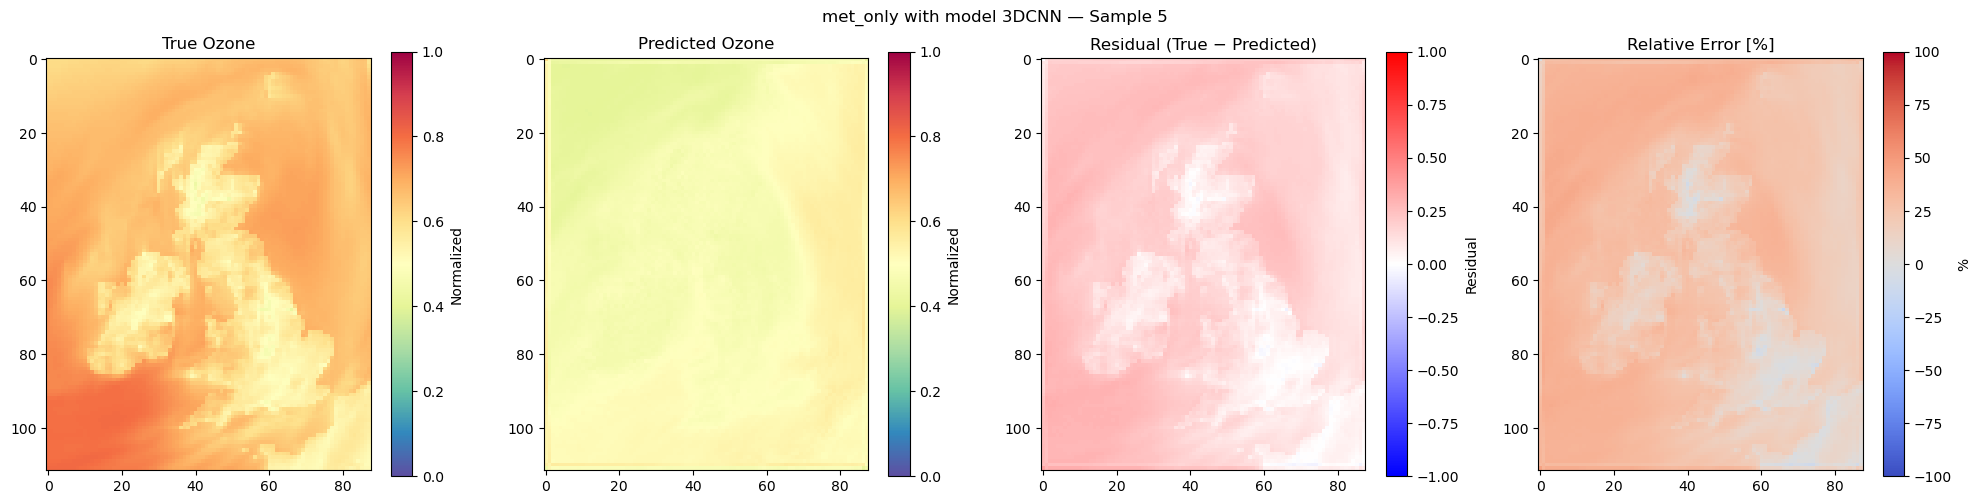

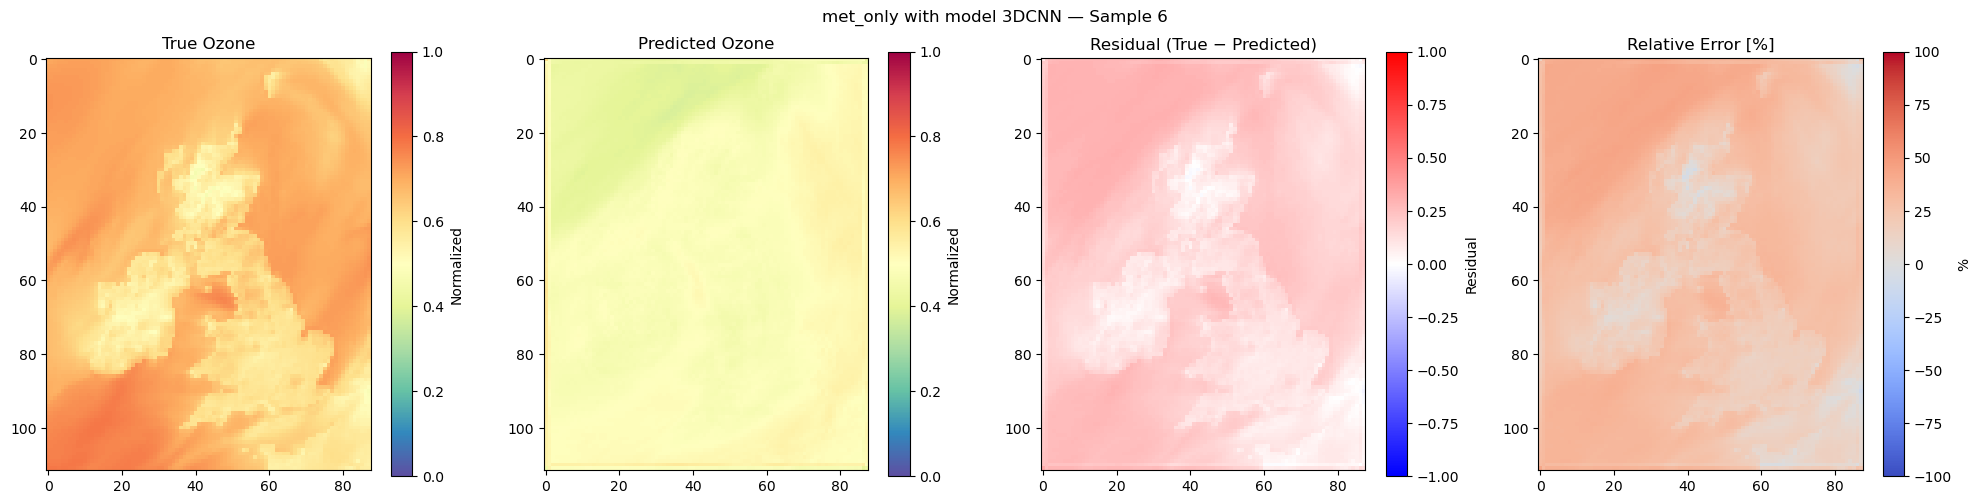

In [ ]:
# Detailed predictions vs true values for the first few time steps, per configuration
if is_running_in_notebook(): # only show visualisations in notebook
    n_show = 6  # number of time steps to visualise per configuration

    for config_name, res in results.items():
        pred          = res["model"].predict(res["xtrain_tensor"][:n_show])
        ytrue         = res["ytrain_tensor"][:n_show]
        residual      = ytrue - pred
        relative_error = tf.where(
            ytrue != 0,
            100 * (residual / ytrue),
            tf.zeros_like(residual),
        )

        print(f"\n=== Predictions: {config_name} with model {model_type} with k={k_folds} folds ===")
        for i in range(n_show):
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            fig.suptitle(f"{config_name} with model {model_type} with k={k_folds} folds — Sample {i + 1}", fontsize=14)

            im0 = axes[0].imshow(ytrue[i, ::-1, :, 0].numpy(), vmin=0, vmax=1, cmap="Spectral_r")
            axes[0].set_title("True Ozone")
            plt.colorbar(im0, ax=axes[0], label="Normalized")

            im1 = axes[1].imshow(pred[i, ::-1, :, 0], vmin=0, vmax=1, cmap="Spectral_r")
            axes[1].set_title("Predicted Ozone")
            plt.colorbar(im1, ax=axes[1], label="Normalized")

            im2 = axes[2].imshow(residual[i, ::-1, :, 0].numpy(), vmin=-1, vmax=1, cmap="bwr")
            axes[2].set_title("Residual (True − Predicted)")
            plt.colorbar(im2, ax=axes[2], label="Residual")

            im3 = axes[3].imshow(relative_error[i, ::-1, :, 0].numpy(), vmin=-100, vmax=100, cmap="coolwarm")
            axes[3].set_title("Relative Error [%]")
            plt.colorbar(im3, ax=axes[3], label="%")

            plt.tight_layout()
            plt.show()